# HealthConnect Experience Lab - Data Preparation, Feature Engineering & Baseline Model
### Week 5: AnalystLab Africa - Data Science Track
**Project:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

**Objective this week:** move from Week 4's problem definition into practical implementation - prepare the data, engineer 
features, define a train/test strategy, train a baseline classification model, and evaluate it. This is a **baseline**, not a final tuned solution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
df["booking_date"] = pd.to_datetime(df["booking_date"])
df["appointment_date"] = pd.to_datetime(df["appointment_date"])
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## Part 1 - Review of Week 4 Foundation

**Problem defined in Week 4:** predict whether a scheduled appointment will result in a **no-show**, framed as a binary classification problem, to help HealthConnect Clinic staff proactively identify at-risk appointments and intervene (e.g. an extra reminder or phone call).

**Week 4 proposed approach:** build the target from `appointment_outcome`, excluding `Cancelled` appointments (a proactive, operationally distinct patient action) from the primary No-Show vs Attended target. Candidate features spanned patient history, appointment characteristics, and clinic-controlled reminder factors.

**Resources used:** `HealthConnect_Appointment_Data.csv` (5,000 appointments) and `HealthConnect_Data_Dictionary.xlsx`.

**Key assumptions/limitations identified in Week 4:**
- Correlations observed were modest, not strong - feasibility of a genuinely useful model was flagged as uncertain and worth testing early.
- Patients can appear multiple times (1,696 unique patients across 5,000 appointments) - a random row-level split risks data leakage.
- The dataset is synthetic, so real-world generalisation is inherently limited.

**Proposed Week 5 focus (from Week 4):** prepare a modelling-ready dataset, implement a leakage-safe train/test split, and train/evaluate a baseline model to test the feasibility assessed qualitatively in Week 4.

This notebook now carries that plan out. **No decisions from Week 4 are silently changed** - where Week 5 analysis suggests a refinement, it is explicitly noted as a documented change, not applied silently.

## Part 2a - Data Preparation

In [2]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.dtypes

Shape: 5000 rows, 18 columns


appointment_id                   object
patient_id                       object
gender                           object
age                               int64
age_group                        object
appointment_type                 object
booking_date             datetime64[ns]
appointment_date         datetime64[ns]
appointment_day                  object
appointment_time                 object
booking_lead_days                 int64
previous_appointments             int64
previous_no_shows                 int64
reminder_sent                    object
reminder_channel                 object
distance_to_clinic_km           float64
waiting_time_minutes            float64
appointment_outcome              object
dtype: object

In [3]:
missing = df.isnull().sum()
missing[missing > 0]

reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64

**Missing values (confirmed consistent with Week 4):** `reminder_channel` (1,366 missing, exactly when `reminder_sent = No`), `distance_to_clinic_km` (90 missing, 1.8%), `waiting_time_minutes` (60 missing, 1.2%). All three are low enough for standard handling without discarding rows.

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate appointment_id:", df['appointment_id'].duplicated().sum())
print("previous_no_shows > previous_appointments (logical error):", (df['previous_no_shows'] > df['previous_appointments']).sum())
print("Negative booking_lead_days:", (df['booking_lead_days'] < 0).sum())
print("Repeated patients:", df['patient_id'].duplicated().sum(), f"({df['patient_id'].nunique()} unique patients across {len(df)} appointments)")

Duplicate rows: 0
Duplicate appointment_id: 0
previous_no_shows > previous_appointments (logical error): 0
Negative booking_lead_days: 0
Repeated patients: 3304 (1696 unique patients across 5000 appointments)


**No duplicates or logically inconsistent records** - confirmed again on the full dataset. The one structural issue relevant to modelling is **not a data error**, but a **data leakage risk**: 3,304 of 5,000 appointments belong to patients who appear more than once. This is addressed directly in the Train/Test Strategy (Part 4) rather than in cleaning, since it is a splitting concern, not a row-level defect.

In [5]:
# Handle missing values
df_prep = df.copy()

# distance_to_clinic_km, waiting_time_minutes: median imputation (low missingness, right-skew-safe choice)
for col in ['distance_to_clinic_km', 'waiting_time_minutes']:
    median_val = df_prep[col].median()
    df_prep[col] = df_prep[col].fillna(median_val)
    print(f"{col}: imputed {df[col].isnull().sum()} missing values with median = {median_val:.1f}")

# reminder_channel: missing is informative (means "no reminder sent"), not a gap to fill in blindly
df_prep['reminder_channel'] = df_prep['reminder_channel'].fillna('None')
print("reminder_channel: filled missing with explicit category 'None' (patients who received no reminder)")

distance_to_clinic_km: imputed 90 missing values with median = 8.7
waiting_time_minutes: imputed 60 missing values with median = 24.0
reminder_channel: filled missing with explicit category 'None' (patients who received no reminder)


**Justification:** median imputation is used for `distance_to_clinic_km` and `waiting_time_minutes` because both are numeric with a small proportion of missing values and some right-skew - the median is more robust to skew than the mean. `reminder_channel` is handled differently: since its missingness is *not random* (it is missing exactly when no reminder was sent), filling it with a median/mode would be misleading. An explicit `'None'` category preserves this meaningful signal instead of erasing it.

In [6]:
# Data type validation
categorical_cols = ['gender', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time',
                     'reminder_sent', 'reminder_channel', 'appointment_outcome']
for col in categorical_cols:
    df_prep[col] = df_prep[col].astype('category')
df_prep.dtypes

appointment_id                   object
patient_id                       object
gender                         category
age                               int64
age_group                      category
appointment_type               category
booking_date             datetime64[ns]
appointment_date         datetime64[ns]
appointment_day                category
appointment_time               category
booking_lead_days                 int64
previous_appointments             int64
previous_no_shows                 int64
reminder_sent                  category
reminder_channel               category
distance_to_clinic_km           float64
waiting_time_minutes            float64
appointment_outcome            category
dtype: object

### Target Variable (carried from Week 4, re-confirmed)

In [7]:
df_prep = df_prep[df_prep['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_prep['no_show'] = (df_prep['appointment_outcome'] == 'No-Show').astype(int)
print(f"Records retained (Attended + No-Show): {len(df_prep)} of {len(df)} ({len(df_prep)/len(df)*100:.1f}%)")
print(df_prep['no_show'].value_counts(normalize=True).round(3) * 100)

Records retained (Attended + No-Show): 4737 of 5000 (94.7%)
no_show
1    51.2
0    48.8
Name: proportion, dtype: float64


**Confirming the Week 4 decision:** Cancelled appointments (263 records) remain excluded from the primary target, for the same reason established in Week 4 a cancellation is a proactive, advance action by the patient, operationally distinct from a silent no-show. No change to this decision was found necessary during Week 5 analysis.

### Irrelevant / Identifier Variables

In [8]:
# appointment_id and raw patient_id are identifiers, not predictive signal — dropped from the feature set
# (patient_id is retained separately below only to support the train/test split and a history feature, then dropped before training)
print("Identifiers to exclude from model features: appointment_id, patient_id (used only for grouping/splitting)")
print("Raw date columns (booking_date, appointment_date) are also excluded as direct features — their useful")
print("signal is already captured by booking_lead_days, appointment_day, and appointment_time.")

Identifiers to exclude from model features: appointment_id, patient_id (used only for grouping/splitting)
Raw date columns (booking_date, appointment_date) are also excluded as direct features — their useful
signal is already captured by booking_lead_days, appointment_day, and appointment_time.


## Part 2b - Data Exploration & Visual Evidence
Each visualisation below is included because it directly informed a preparation, feature engineering, or modelling decision — not simply to meet a count.

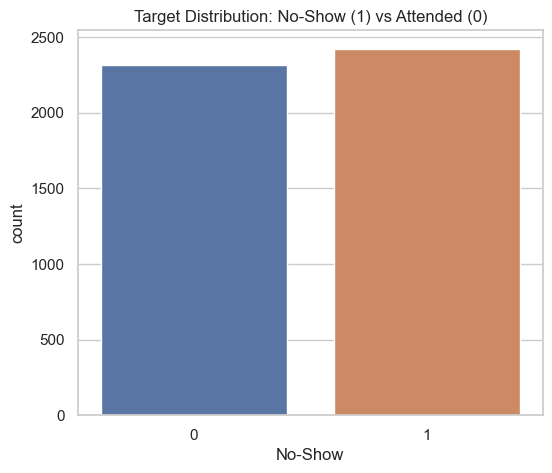

In [9]:
plt.figure(figsize=(6,5))
sns.countplot(data=df_prep, x='no_show', hue='no_show', palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Target Distribution: No-Show (1) vs Attended (0)')
plt.xlabel('No-Show')
plt.show()

**What it shows / decision informed:** the target is close to balanced (51.2% No-Show / 48.8% Attended). **Decision:** no class-imbalance correction (e.g. SMOTE, class weighting) is applied for this baseline it would add complexity without a clear need given this balance.

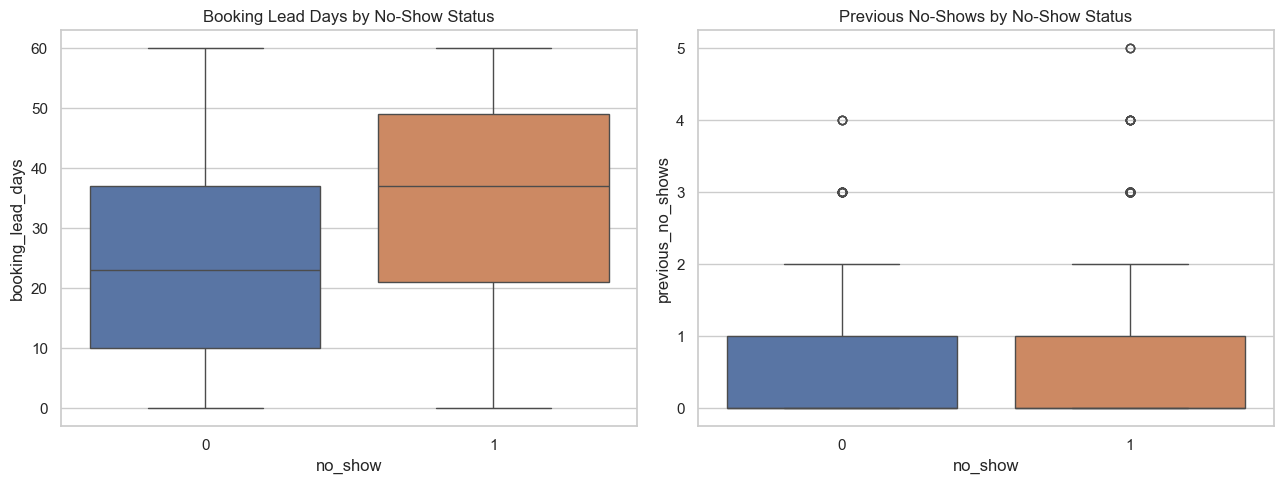

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_prep, x='no_show', y='booking_lead_days', hue='no_show', palette=['#4C72B0','#DD8452'], legend=False, ax=axes[0])
axes[0].set_title('Booking Lead Days by No-Show Status')
sns.boxplot(data=df_prep, x='no_show', y='previous_no_shows', hue='no_show', palette=['#4C72B0','#DD8452'], legend=False, ax=axes[1])
axes[1].set_title('Previous No-Shows by No-Show Status')
plt.tight_layout()
plt.show()

**What it shows:** appointments that end in a no-show tend to have been booked further in advance, and patients with more prior no-shows are visibly more likely to no-show again. **Decision informed:** both `booking_lead_days` and `previous_no_shows` are retained as core features and prioritised in the feature list; this also supports engineering a `no_show_rate_history` feature (Part 3), since raw prior no-shows alone doesn't account for how many appointments a patient has had in total.

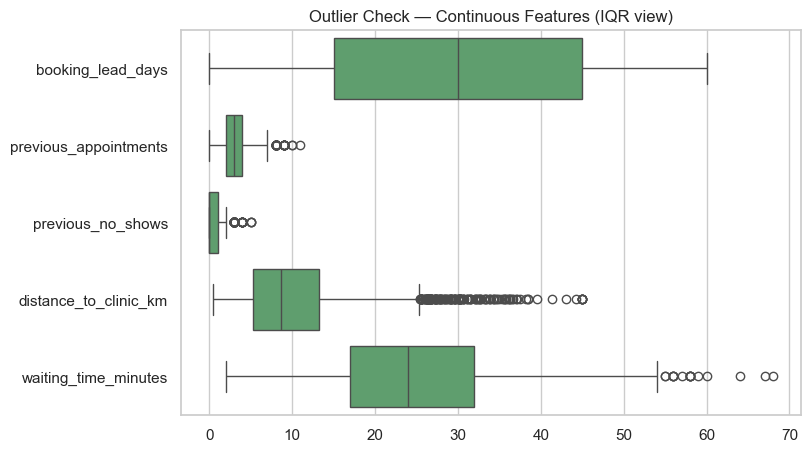

In [11]:
plt.figure(figsize=(8,5))
outlier_check = df_prep[['booking_lead_days','previous_appointments','previous_no_shows','distance_to_clinic_km','waiting_time_minutes']]
sns.boxplot(data=outlier_check, orient='h', color='#55A868')
plt.title('Outlier Check — Continuous Features (IQR view)')
plt.show()

**What it shows:** `waiting_time_minutes` and `distance_to_clinic_km` show a modest number of upper outliers; `booking_lead_days` and history counts are well-behaved. **Decision informed:** given the baseline model will include a tree-based option (Random Forest, robust to outliers) alongside Logistic Regression, no aggressive outlier removal is applied at this stage - flagged instead as a Week 6 refinement if Logistic Regression performance is notably hurt by these values.

<Figure size 700x500 with 0 Axes>

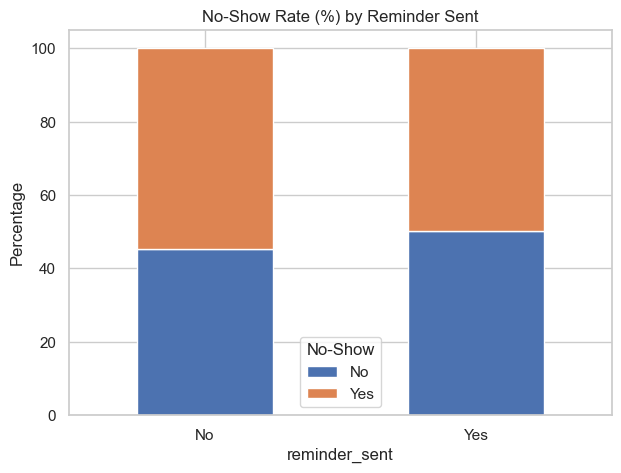

In [12]:
plt.figure(figsize=(7,5))
ct = pd.crosstab(df_prep['reminder_sent'], df_prep['no_show'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#4C72B0', '#DD8452'], figsize=(7,5))
plt.title('No-Show Rate (%) by Reminder Sent')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='No-Show', labels=['No', 'Yes'])
plt.show()

**What it shows:** no-show rate is only marginally different between patients who did and didn't receive a reminder in this dataset. **Decision informed:** `reminder_sent`/`reminder_channel` are still retained as features (they are actionable and clinically meaningful even if weak here), but this tempers expectations that reminder-related features alone will drive strong model performance.

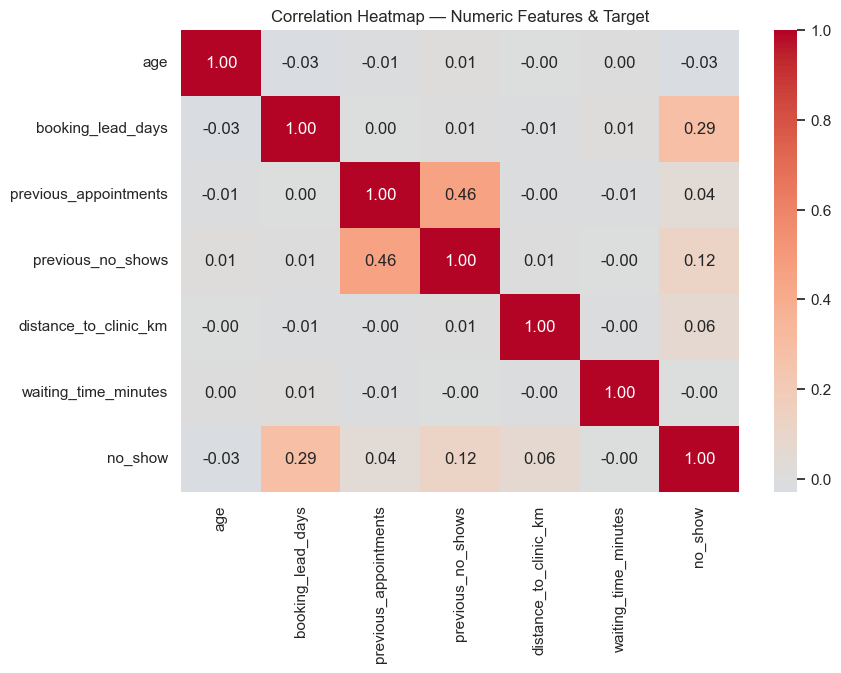

In [13]:
plt.figure(figsize=(9,6))
corr_cols = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
             'distance_to_clinic_km', 'waiting_time_minutes', 'no_show']
corr = df_prep[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features & Target')
plt.show()

**What it shows:** confirms Week 4's early read `booking_lead_days` (r ≈ 0.29) and `previous_no_shows` (r ≈ 0.12) are the strongest individual numeric correlates of no-show; no pair of predictor features is highly correlated with each other, so no redundancy needs to be resolved before modelling.

## Part 3 - Feature Engineering

In [14]:
# 1. no_show_rate_history — a patient's own historical no-show rate (more informative than the raw count alone)
df_prep['no_show_rate_history'] = np.where(
    df_prep['previous_appointments'] > 0,
    df_prep['previous_no_shows'] / df_prep['previous_appointments'],
    0
)

# 2. is_new_patient — flags patients with no prior appointment history
df_prep['is_new_patient'] = (df_prep['previous_appointments'] == 0).astype(int)

# 3. long_lead_time — flags bookings made well in advance, based on the pattern seen in Part 2b
lead_75th = df_prep['booking_lead_days'].quantile(0.75)
df_prep['long_lead_time'] = (df_prep['booking_lead_days'] > lead_75th).astype(int)

# 4. reminder_received — simplifies reminder_sent/channel into a single actionable binary flag
df_prep['reminder_received'] = (df_prep['reminder_sent'] == 'Yes').astype(int)

# 5. is_weekend_appointment — weekend vs weekday attendance patterns can differ
df_prep['is_weekend_appointment'] = df_prep['appointment_day'].isin(['Saturday', 'Sunday']).astype(int)

df_prep[['previous_no_shows','previous_appointments','no_show_rate_history','is_new_patient',
         'booking_lead_days','long_lead_time','reminder_received','appointment_day','is_weekend_appointment']].head()

,previous_no_shows,previous_appointments,no_show_rate_history,is_new_patient,booking_lead_days,long_lead_time,reminder_received,appointment_day,is_weekend_appointment
0,0,2,0.000000,0,12,0,1,Tuesday,0
1,0,6,0.000000,0,2,0,1,Friday,0
2,1,5,0.200000,0,38,0,1,Wednesday,0
3,1,3,0.333333,0,41,0,1,Thursday,0
4,1,3,0.333333,0,47,1,1,Monday,0


**Feature 1 - `no_show_rate_history`:** *What:* a patient's historical no-show rate (previous no-shows ÷ previous appointments, 0 for new patients). *Why:* the raw count of previous no-shows does not account for how many chances a patient has had  two patients with 2 prior no-shows out of 3 appointments vs. out of 20 have very different risk profiles. *Expected value:* a more precise behavioural risk signal than the raw count alone.

**Feature 2 - `is_new_patient`:** *What:* binary flag for patients with zero prior appointments. *Why:* Week 4 flagged that history-based features have no signal for first-time patients; this feature lets the model treat that group distinctly rather than defaulting them to a `0.0` history rate that looks identical to a long-time perfect attender. *Expected value:* prevents new patients from being systematically mis-scored by history-based features.

**Feature 3 - `long_lead_time`:** *What:* binary flag for bookings in the top quartile of lead time. *Why:* Part 2b showed a visible relationship between longer lead times and no-shows; binning the top quartile gives the model (especially Logistic Regression) an easy, interpretable threshold signal in addition to the raw continuous value. *Expected value:* may capture a non-linear "too far in advance" effect that a purely linear treatment of `booking_lead_days` could under-represent.

**Feature 4 - `reminder_received`:** *What:* a clean binary version of `reminder_sent` (already binary, but explicitly renamed/typed for the modelling pipeline). *Why:* makes the clinic-actionable lever explicit and simple to interpret in model coefficients. *Expected value:* directly interpretable for the clinic ("did sending a reminder change predicted risk?").

**Feature 5 - `is_weekend_appointment`:** *What:* binary flag for Saturday/Sunday appointments. *Why:* attendance patterns often differ on weekends (different patient routines, clinic hours); domain reasoning suggests this is worth testing even though it wasn't examined in Week 4. *Expected value:* may capture a scheduling effect not visible in the day-of-week variable treated as a plain nominal category.

## Part 4 - Train/Test Strategy

In [15]:
# Sort by appointment_date to enable a time-based split
df_sorted = df_prep.sort_values('appointment_date').reset_index(drop=True)
split_index = int(len(df_sorted) * 0.8)
split_date = df_sorted.iloc[split_index]['appointment_date']
print(f"Time-based split point: {split_date.date()}  (80% train / 20% test by date)")

train_df = df_sorted[df_sorted['appointment_date'] < split_date].copy()
test_df = df_sorted[df_sorted['appointment_date'] >= split_date].copy()
print(f"Train: {len(train_df)} appointments ({train_df['appointment_date'].min().date()} to {train_df['appointment_date'].max().date()})")
print(f"Test:  {len(test_df)} appointments ({test_df['appointment_date'].min().date()} to {test_df['appointment_date'].max().date()})")

# Check for patient overlap between train and test (informational — not corrected for in this baseline)
overlap = set(train_df['patient_id']) & set(test_df['patient_id'])
print(f"\nPatients appearing in both train and test: {len(overlap)} of {df_prep['patient_id'].nunique()} total unique patients")

Time-based split point: 2026-03-13  (80% train / 20% test by date)
Train: 3789 appointments (2025-01-01 to 2026-03-12)
Test:  948 appointments (2026-03-13 to 2026-06-30)

Patients appearing in both train and test: 657 of 1680 total unique patients


**Strategy chosen: time-based split (80% earliest appointments for training, 20% most recent for testing), not a random row-level split.**

**Justification:** in real deployment, the clinic would use a model trained on historical appointments to predict outcomes for *future* appointments  a random split would let the model "see the future" during training, producing an unrealistically optimistic performance estimate that would not hold up in practice. A time-based split better simulates genuine deployment conditions.

**Documented limitation (not silently ignored):** some patients still appear in both the train and test periods, since patients naturally return for multiple appointments over time this is expected and, in this case, *desirable*: it reflects how a real deployed model would encounter both new and returning patients. A stricter patient-level split (ensuring no patient ID appears in both sets) was considered, but rejected for this baseline because it would remove exactly the returning-patient history signal (`no_show_rate_history`, `previous_no_shows`) that Part 2b identified as one of the strongest predictors testing on only "unseen" patients would evaluate a harder, different problem than the one HealthConnect actually faces. This trade-off is flagged explicitly as a modelling consideration for Week 6, rather than resolved silently in either direction.

## Part 5 - Baseline Model

### Encoding and Feature Assembly
The engineered and original numeric features are combined with One-Hot Encoded versions of the nominal categorical variables (`gender`, `appointment_type`, `appointment_day`, `appointment_time`, `reminder_channel`). One-Hot Encoding is used because none of these categories have a natural order  a plain numeric Label Encoding would incorrectly imply, for example, that "Evening" is mathematically greater than "Morning". `drop_first=True` avoids the classic dummy-variable trap (perfect multicollinearity between the dummy columns), which matters specifically for Logistic Regression's coefficient stability. Train and test feature columns are explicitly aligned afterward, in case a rare category happens to appear in only one of the two time periods.

In [16]:
feature_cols = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                'distance_to_clinic_km', 'waiting_time_minutes', 'no_show_rate_history',
                'is_new_patient', 'long_lead_time', 'reminder_received', 'is_weekend_appointment']
categorical_features = ['gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_channel']

def encode_features(frame):
    encoded = frame[feature_cols].copy()
    dummies = pd.get_dummies(frame[categorical_features], drop_first=True)
    return pd.concat([encoded, dummies], axis=1)

X_train = encode_features(train_df)
X_test = encode_features(test_df)
# Align columns in case a category is missing from one split
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
y_train = train_df['no_show']
y_test = test_df['no_show']

print(f"Training features: {X_train.shape[1]}, Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Training features: 27, Train rows: 3789, Test rows: 948


### Feature Scaling
Logistic Regression estimates coefficients using distance-sensitive optimisation, so features on very different numeric scales (e.g. `age` in tens vs `distance_to_clinic_km` potentially in larger ranges) can distort the fitted model if left unscaled. `StandardScaler` is fitted **only on the training set** and then applied to both train and test fitting on the full dataset (including test data) would leak information about the test set's distribution into training, a subtle but important data-leakage mistake to avoid. Random Forest does not require this step, since tree-based splits are scale-invariant.

In [17]:
# Scale continuous features for Logistic Regression (tree-based models don't require this)
scaler = StandardScaler()
numeric_to_scale = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                     'distance_to_clinic_km', 'waiting_time_minutes', 'no_show_rate_history']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test_scaled[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])

In [18]:
# Baseline Model 1: Logistic Regression — chosen as the primary baseline for its interpretability,
# which matters for a healthcare-adjacent decision-support tool that clinic staff need to trust and understand.
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained.")

Logistic Regression trained.


In [19]:
# Baseline Model 2 (comparison): Random Forest — to check whether non-linear relationships add value
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("Random Forest trained.")

Random Forest trained.


**Model selection reasoning:** Logistic Regression is the primary baseline, chosen specifically for interpretability  for a tool intended to support (not replace) clinic staff decisions, being able to explain *why* an appointment is flagged as high-risk (via model coefficients) is valuable, echoing the transparency expectations set out in the HealthConnect Knowledge Base for AI-supported tools. Random Forest is trained as a comparison point to check whether the modest, largely linear relationships observed in Part 2b leave meaningful non-linear signal on the table.

**Training process:** both models are trained on the time-based training split (appointments before the 80th-percentile date) using the engineered feature set from Part 3 plus one-hot encoded categorical variables. Continuous features are standardised for Logistic Regression only, since Random Forest is scale-invariant.

## Part 6 - Initial Evaluation

In [20]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"=== {name} ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.3f}")
    print()

evaluate("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)

=== Logistic Regression ===
Accuracy:  0.618
Precision: 0.624
Recall:    0.631
F1-score:  0.628
ROC-AUC:   0.677

=== Random Forest ===
Accuracy:  0.620
Precision: 0.626
Recall:    0.634
F1-score:  0.630
ROC-AUC:   0.672



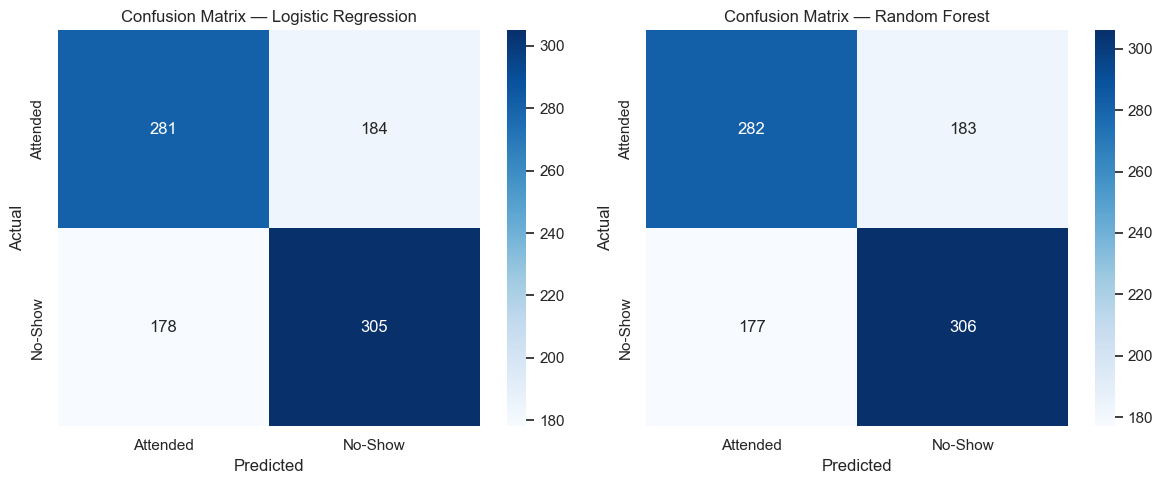

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Attended','No-Show'], yticklabels=['Attended','No-Show'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

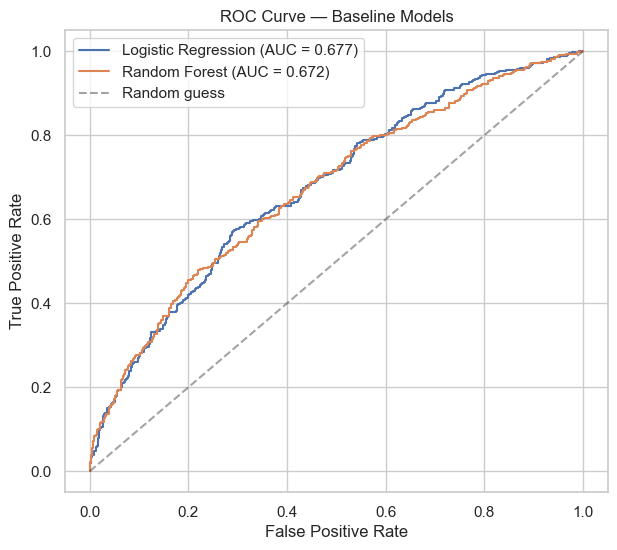

In [22]:
plt.figure(figsize=(7,6))
for name, y_proba in [("Logistic Regression", y_proba_lr), ("Random Forest", y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Models')
plt.legend()
plt.show()

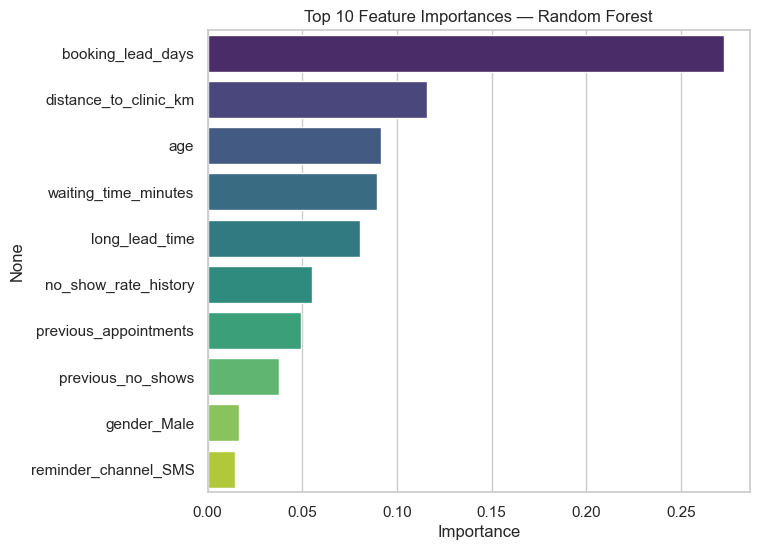

In [23]:
plt.figure(figsize=(7,6))
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()

**Interpretation of results:** both baseline models perform *modestly above chance* but are far from strongly predictive ROC-AUC of ~0.67-0.68 for both models indicates weak-to-moderate discrimination, clearly better than random guessing (0.5) but well short of a highly reliable predictor. This is broadly consistent with the moderate correlations flagged as a risk back in Week 4. The Random Forest feature importance ranking shows `booking_lead_days` as by far the strongest individual signal, followed by `distance_to_clinic_km`, `age`, `waiting_time_minutes`, and the engineered `long_lead_time` flag  with `no_show_rate_history` and the raw history counts (`previous_appointments`, `previous_no_shows`) contributing real but comparatively smaller importance. This is a useful, slightly counter-intuitive finding: the exploratory analysis in Part 2b suggested patient history would be a dominant signal, but the trained model relies more heavily on booking/logistics factors (lead time, distance, waiting time) than on a patient's own no-show track record  worth flagging explicitly for Week 6 rather than assuming Part 2b's visual read directly predicts final model behaviour.

**What this means for the project:** the baseline confirms the problem is *tractable but not easy*  there is genuine, usable signal in the data (performance is meaningfully better than random guessing), but this synthetic dataset does not support a highly accurate predictor from these features alone. This is a realistic and useful finding to report to the HealthConnect project, not a failure of the modelling approach.

## Modelling Limitations

**Technical limitations:**
- Both baseline models show limited discriminative power (ROC-AUC ≈ 0.67-0.68)  this is an honest baseline result, not yet a production-ready predictor. In practical terms, the model is correct roughly two-thirds of the time it discriminates between a random no-show and a random attendee  useful for prioritisation, not yet reliable enough for high-stakes automated decisions.
- The time-based split, while more realistic than a random split, still allows the same patient to appear in both train and test periods (documented and justified in Part 4)  a modelling trade-off, not an oversight. This means the reported performance may be *slightly* optimistic relative to how the model would perform on genuinely new patients only; the Week 6 patient-level split check will quantify this gap.
- No hyperparameter tuning was performed at this baseline stage, consistent with the Week 5 brief's focus on establishing a reliable baseline rather than a final best-performing model. Both models were run with reasonable default/moderate settings, not optimised ones.
- The dataset is synthetic; any real-world deployment would require revalidation on genuine clinic data, since synthetic data generation processes can embed patterns (or omit real-world noise) that do not perfectly reflect an actual clinic's population.

**Business and data limitations:**
- The dataset provides no information on *why* a patient missed an appointment (e.g. transport failure, illness, forgetfulness, work conflict)  the model can flag risk, but cannot yet explain the underlying cause, which limits how targeted an intervention can be.
- Sample size (5,000 appointments, 1,696 unique patients) is reasonable for a baseline but modest for a healthcare setting; rare but important subgroups (e.g. a specific appointment type at a specific clinic location) may be underrepresented, and performance for those subgroups has not been separately verified in this baseline.
- The model was evaluated in aggregate; no fairness or subgroup analysis (e.g. checking whether prediction quality differs meaningfully by age group or gender) has yet been performed  this is an important gap to close before any operational use, not just a technical nicety, given the healthcare context.
- Findings reflect a single historical period and dataset snapshot; appointment attendance behaviour can shift over time (e.g. after a clinic changes its reminder process), so the model would need periodic retraining and monitoring rather than being treated as a one-time deliverable.

## Business Recommendations

Translating the technical findings above into concrete, actionable guidance for HealthConnect Clinic decision-makers -**prioritised by expected organisational impact**, from highest to lowest.

**Priority 1 (High impact, low effort) - Pilot a targeted second reminder for long-lead-time bookings.** Since `booking_lead_days` is the single strongest predictor of no-shows, this is the most direct, lowest-cost lever available: a closer-to-date reminder specifically for appointments booked beyond the ~75th-percentile lead time identified in this analysis. High expected impact because it targets the strongest signal in the data; low effort because it extends an existing process (reminders) rather than building something new.

**Priority 2 (High impact, medium effort) - Use model output to prioritise staff follow-up time, not as an automated gatekeeper.** Given the current ROC-AUC (~0.67-0.68), the highest-value near-term use of this work is as a daily ranked list that helps staff focus limited follow-up capacity (e.g. a phone call) on the highest-risk bookings. High impact because it makes every existing staff hour more effective; medium effort because it requires a simple internal workflow change, not new infrastructure.

**Priority 3 (Medium impact, medium effort) - Investigate practical support for high-distance patients.** `distance_to_clinic_km` ranked as the second most important feature. A telehealth option for suitable appointment types, or coordinated transport-assistance information for high-distance/high-risk appointments, could meaningfully reduce a structural (not just behavioural) barrier to attendance. Medium effort since it may require new service options, not just a data-driven flag.

**Priority 4 (Medium impact, low effort) - Re-examine the current reminder process itself.** The data shows only a marginal attendance difference between patients who did and didn't receive a reminder a useful, low-cost diagnostic finding suggesting the *current* reminder timing, content, or channel may already have room to improve, independent of any new model.

**Priority 5 (Foundational, ongoing effort) - Plan a staged rollout with a defined success metric.** Lower urgency than the above but essential before scaling: an internal staff pilot with human review of flagged appointments, and an upfront definition of what "success" looks like operationally (e.g. a target reduction in no-show rate among flagged high-risk appointments), so that Week 6+ refinements are judged against a concrete business goal rather than technical metrics alone.

**Key assumptions underlying these recommendations** (see also Limitations below): that the historical appointment patterns in this dataset are representative of HealthConnect's real patient population; that a modest predictive signal (ROC-AUC ~0.67-0.68) is still operationally useful for *prioritisation* even though it would not support fully automated decisions; and that clinic staff have some available capacity to act on a risk-ranked list (i.e. the bottleneck is knowing who to prioritise, not having zero follow-up capacity at all).

## Cross-Track Collaboration

**Track interacted with (conceptually, via shared project resources):** Data Analytics.

**What was exchanged:** the Data Analytics track's Week 4 output proposed candidate KPIs built from several of the same variables used here as Data Science features notably `previous_no_shows`, `distance_to_clinic_km`, and reminder-related fields. Aligning on these shared variables (definitions taken directly from the common `HealthConnect_Data_Dictionary.xlsx`) ensured the Data Science feature set and the Data Analytics KPI definitions describe the same underlying concepts consistently across tracks.

**Why relevant:** if Data Science features and Data Analytics KPIs used inconsistent definitions of the same variable (e.g. a different `no_show_rate` calculation), stakeholders reviewing both outputs side by side would see contradictory numbers for what should be the same underlying pattern.

**What improved as a result:** the engineered `no_show_rate_history` feature (Part 3) mirrors the kind of rate-based KPI the Data Analytics track would also calculate at the aggregate level, making it easier for a shared HealthConnect dashboard (or final presentation) to present Data Science and Data Analytics findings coherently side by side, rather than as two disconnected analyses.

## Recommendations for Week 6

1. **Hyperparameter tuning:** systematically tune Random Forest (and/or try Gradient Boosting) to check whether the current performance ceiling can be pushed meaningfully higher.
2. **Feature refinement:** revisit `distance_to_clinic_km` and `waiting_time_minutes`, which showed weak individual signal consider interaction features (e.g. distance × appointment_type) rather than discarding them outright.
3. **Split strategy sensitivity check:** re-run the baseline with a strict patient-level split (no patient in both train and test) as a robustness check against the time-based split used here, and compare results directly.
4. **Threshold selection:** since the clinic's priority is likely to catch as many true no-shows as possible (recall on the No-Show class), evaluate adjusting the classification threshold away from the default 0.5 and quantify the resulting precision/recall trade-off in business terms (e.g. cost of an unnecessary reminder vs. cost of a missed no-show).
5. **Coordinate with Project Management** on how model outputs would practically reach clinic staff (e.g. a daily risk list) once performance is validated further.